In [1]:
# Instalamos las dependencias adicionales necesarias para el proyecto.
!pip -q install joblib fastapi uvicorn pydantic

# Mostramos un mensaje de confirmación.
print("Dependencias instaladas correctamente.")

Dependencias instaladas correctamente.


In [2]:
# Importamos el manejo del sistema operativo.
import os

# Importamos herramientas para trabajar con rutas.
from pathlib import Path

# Importamos herramientas para guardar información JSON.
import json

# Importamos herramientas para copiar archivos.
import shutil

# Importamos herramientas para liberar memoria.
import gc

# Importamos NumPy para cálculos numéricos.
import numpy as np

# Importamos Pandas para procesamiento de datos.
import pandas as pd

# Importamos Matplotlib para generar gráficas.
import matplotlib.pyplot as plt

# Importamos Joblib para guardar los preprocesadores.
import joblib

# Importamos TensorFlow para las redes neuronales.
import tensorflow as tf

# Importamos métricas de Scikit-learn.
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Importamos StandardScaler para normalizar los datos.
from sklearn.preprocessing import StandardScaler

# Definimos una semilla para mejorar la reproducibilidad.
RANDOM_SEED = 42

# Configuramos la semilla de NumPy.
np.random.seed(RANDOM_SEED)

# Configuramos la semilla de TensorFlow.
tf.random.set_seed(RANDOM_SEED)

# Intentamos activar operaciones deterministas.
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

# Mostramos la versión de TensorFlow.
print("TensorFlow:", tf.__version__)

# Mostramos si existe una GPU disponible.
print("GPU disponible:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.21.0
GPU disponible: []


In [3]:
# Importamos el cargador de archivos de Google Colab.
from google.colab import files

# Permitimos seleccionar el CSV desde el computador.
uploaded = files.upload()

# Mostramos los archivos cargados.
print("Archivos cargados:", list(uploaded.keys()))

Saving dataset_demanda_energia_LSTM_2025_2026.csv to dataset_demanda_energia_LSTM_2025_2026 (1).csv
Archivos cargados: ['dataset_demanda_energia_LSTM_2025_2026 (1).csv']


In [4]:
# Definimos los posibles nombres del dataset.
file_candidates = [
    "/content/ataset_demanda_energia_LSTM_2025_2026.csv",
    "/content/dataset_demanda_energia_LSTM_2025_2026.csv"
]

# Inicializamos la ruta encontrada.
file_path = None

# Recorremos los posibles nombres.
for candidate in file_candidates:
    # Verificamos si el archivo existe.
    if os.path.exists(candidate):
        # Guardamos la ruta encontrada.
        file_path = candidate
        # Terminamos la búsqueda.
        break

# Generamos un error si no encontramos el archivo.
if file_path is None:
    raise FileNotFoundError(
        "No se encontró el archivo atataset/dataset_demanda_energia_LSTM_2025_2026.csv."
    )

# Cargamos automáticamente el separador del CSV.
raw_df = pd.read_csv(
    file_path,
    sep=None,
    engine="python"
)

# Mostramos el tamaño original.
print("Dimensiones originales:", raw_df.shape)

# Mostramos las primeras filas.
display(raw_df.head())

# Mostramos los nombres originales de las columnas.
print("Columnas originales:")
print(raw_df.columns.tolist())

Dimensiones originales: (17550, 15)


,timestamp,demanda_mw,temperatura_c,humedad_pct,viento_kmh,radiacion_wm2,precipitacion_mm,precio_kwh,hora,dia_semana,fin_semana,festivo,mes,periodo_dia,demanda_objetivo
0,2025-05-11 08:00:00,578.27,19.94,52.31,12.98,445.51,0.00,29.5028,8,6,1,0,5,mañana,573.67
1,2026-07-21 05:00:00,734.79,21.51,61.71,16.04,0.00,4.56,18.9739,5,1,0,0,7,madrugada,758.59
2,2025-08-21 00:00:00,698.80,24.00,94.25,16.15,0.00,0.00,18.9476,0,3,0,0,8,madrugada,705.37
3,2025-08-18 17:00:00,787.40,24.39,63.25,6.15,83.32,0.00,31.7882,17,0,0,0,8,tarde,804.35
4,2026-04-19 09:00:00,522.11,19.65,55.63,14.01,556.14,0.00,35.2807,9,6,1,0,4,mañana,526.36


Columnas originales:
['timestamp', 'demanda_mw', 'temperatura_c', 'humedad_pct', 'viento_kmh', 'radiacion_wm2', 'precipitacion_mm', 'precio_kwh', 'hora', 'dia_semana', 'fin_semana', 'festivo', 'mes', 'periodo_dia', 'demanda_objetivo']


In [5]:
# Importamos herramientas para normalización de texto.
import unicodedata

# Creamos una función para normalizar nombres y textos.
def normalize_text(value):
    # Retornamos NaN cuando el dato está vacío.
    if pd.isna(value):
        return np.nan

    # Convertimos el valor a texto.
    text = str(value)

    # Eliminamos espacios externos.
    text = text.strip()

    # Convertimos el texto a minúsculas.
    text = text.lower()

    # Separamos caracteres Unicode.
    text = unicodedata.normalize("NFKD", text)

    # Eliminamos acentos.
    text = "".join(
        character
        for character in text
        if not unicodedata.combining(character)
    )

    # Retornamos el texto normalizado.
    return text


# Creamos una función para convertir valores numéricos contaminados con texto.
def clean_numeric_series(series):
    # Convertimos temporalmente los valores a texto.
    cleaned = series.astype(str)

    # Eliminamos espacios externos.
    cleaned = cleaned.str.strip()

    # Cambiamos coma decimal por punto.
    cleaned = cleaned.str.replace(",", ".", regex=False)

    # Extraemos el primer número válido encontrado.
    cleaned = cleaned.str.extract(r"(-?\d+(?:\.\d+)?)", expand=False)

    # Convertimos el resultado a número.
    cleaned = pd.to_numeric(cleaned, errors="coerce")

    # Retornamos la serie limpia.
    return cleaned


# Creamos una función para normalizar variables binarias.
def normalize_binary(value):
    # Retornamos NaN si el dato está vacío.
    if pd.isna(value):
        return np.nan

    # Normalizamos el texto.
    text = normalize_text(value)

    # Definimos valores interpretados como verdadero.
    true_values = {
        "1",
        "si",
        "yes",
        "true",
        "verdadero",
        "festivo"
    }

    # Definimos valores interpretados como falso.
    false_values = {
        "0",
        "no",
        "false",
        "falso",
        "laboral",
        "no festivo"
    }

    # Retornamos uno cuando el valor es verdadero.
    if text in true_values:
        return 1

    # Retornamos cero cuando el valor es falso.
    if text in false_values:
        return 0

    # Intentamos interpretar directamente números.
    try:
        number = float(text)

        # Aceptamos únicamente cero o uno.
        if number in [0.0, 1.0]:
            return int(number)
    except Exception:
        pass

    # Retornamos NaN si el valor es desconocido.
    return np.nan


# Creamos una función para obtener el periodo del día.
def get_day_period(hour):
    # Clasificamos las horas entre medianoche y las cinco.
    if 0 <= hour <= 5:
        return "madrugada"

    # Clasificamos las horas entre seis y once.
    if 6 <= hour <= 11:
        return "manana"

    # Clasificamos las horas entre doce y diecisiete.
    if 12 <= hour <= 17:
        return "tarde"

    # Las demás horas pertenecen a la noche.
    return "noche"

In [6]:
# Creamos una copia para mantener intactos los datos originales.
df = raw_df.copy()

# Normalizamos los nombres de las columnas.
df.columns = [
    normalize_text(column).replace(" ", "_")
    for column in df.columns
]

# Definimos las columnas mínimas que necesitamos encontrar.
required_columns = [
    "timestamp",
    "demanda_mw",
    "temperatura_c",
    "humedad_pct",
    "viento_kmh",
    "radiacion_wm2",
    "precipitacion_mm",
    "precio_kwh",
    "festivo"
]

# Detectamos columnas requeridas que no existan.
missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

# Detenemos la ejecución si faltan variables indispensables.
if missing_columns:
    raise ValueError(
        f"Faltan columnas obligatorias: {missing_columns}"
    )

# Guardamos la cantidad inicial de registros.
initial_rows = len(df)

# Eliminamos duplicados exactamente iguales.
df = df.drop_duplicates().copy()

# Guardamos cuántos duplicados exactos se eliminaron.
exact_duplicates_removed = initial_rows - len(df)

# Convertimos timestamp al formato de fecha.
df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    errors="coerce",
    format="mixed",
    dayfirst=True
)

# Contamos timestamps inválidos.
invalid_timestamps = df["timestamp"].isna().sum()

# Eliminamos los timestamps que no pudieron interpretarse.
df = df.dropna(subset=["timestamp"]).copy()

# Definimos las variables numéricas originales.
numeric_columns = [
    "demanda_mw",
    "temperatura_c",
    "humedad_pct",
    "viento_kmh",
    "radiacion_wm2",
    "precipitacion_mm",
    "precio_kwh"
]

# Limpiamos cada variable numérica.
for column in numeric_columns:
    df[column] = clean_numeric_series(df[column])

# Normalizamos la variable festivo.
df["festivo"] = df["festivo"].apply(normalize_binary)

# Ordenamos los registros cronológicamente.
df = df.sort_values("timestamp").reset_index(drop=True)

# Mostramos información parcial.
print("Duplicados exactos eliminados:", exact_duplicates_removed)
print("Timestamps inválidos eliminados:", invalid_timestamps)
print("Registros restantes:", len(df))

Duplicados exactos eliminados: 30
Timestamps inválidos eliminados: 0
Registros restantes: 17520


In [7]:
# Contamos cuántos timestamps aparecen más de una vez.
duplicated_timestamp_count = df.duplicated(
    subset=["timestamp"],
    keep=False
).sum()

# Calculamos cuántos valores faltantes tiene cada registro.
df["_missing_count"] = df.isna().sum(axis=1)

# Ordenamos primero por timestamp y después por cantidad de faltantes.
df = df.sort_values(
    ["timestamp", "_missing_count"],
    ascending=[True, True]
)

# Conservamos el registro más completo para cada timestamp.
df = df.drop_duplicates(
    subset=["timestamp"],
    keep="first"
)

# Eliminamos la columna auxiliar.
df = df.drop(columns=["_missing_count"])

# Volvemos a ordenar cronológicamente.
df = df.sort_values("timestamp").reset_index(drop=True)

# Mostramos cuántos registros participaron en conflictos temporales.
print(
    "Registros asociados a timestamps duplicados:",
    duplicated_timestamp_count
)

# Mostramos el total después del proceso.
print("Registros después de resolver timestamps:", len(df))

Registros asociados a timestamps duplicados: 0
Registros después de resolver timestamps: 17520


In [8]:
# Creamos contadores para las reglas físicas.
physical_invalid_counts = {}

# Detectamos demandas negativas.
invalid_mask = df["demanda_mw"] < 0

# Guardamos la cantidad encontrada.
physical_invalid_counts["demanda_mw"] = int(invalid_mask.sum())

# Convertimos esos registros a NaN para posteriormente eliminarlos.
df.loc[invalid_mask, "demanda_mw"] = np.nan


# Detectamos humedad fuera del rango físico de 0 a 100.
invalid_mask = (
    (df["humedad_pct"] < 0)
    | (df["humedad_pct"] > 100)
)

# Guardamos la cantidad.
physical_invalid_counts["humedad_pct"] = int(invalid_mask.sum())

# Marcamos esos valores como inválidos.
df.loc[invalid_mask, "humedad_pct"] = np.nan


# Detectamos velocidades de viento negativas.
invalid_mask = df["viento_kmh"] < 0

# Guardamos la cantidad.
physical_invalid_counts["viento_kmh"] = int(invalid_mask.sum())

# Marcamos esos valores como inválidos.
df.loc[invalid_mask, "viento_kmh"] = np.nan


# Detectamos radiación negativa.
invalid_mask = df["radiacion_wm2"] < 0

# Guardamos la cantidad.
physical_invalid_counts["radiacion_wm2"] = int(invalid_mask.sum())

# Marcamos esos valores como inválidos.
df.loc[invalid_mask, "radiacion_wm2"] = np.nan


# Detectamos precipitación negativa.
invalid_mask = df["precipitacion_mm"] < 0

# Guardamos la cantidad.
physical_invalid_counts["precipitacion_mm"] = int(invalid_mask.sum())

# Marcamos esos valores como inválidos.
df.loc[invalid_mask, "precipitacion_mm"] = np.nan


# Mostramos el resumen.
print("Valores físicamente inconsistentes:")
print(physical_invalid_counts)

Valores físicamente inconsistentes:
{'demanda_mw': 0, 'humedad_pct': 9, 'viento_kmh': 8, 'radiacion_wm2': 0, 'precipitacion_mm': 0}


In [9]:
# Definimos el tamaño histórico para detectar anomalías.
ANOMALY_WINDOW = 168

# Definimos el mínimo de observaciones necesarias.
ANOMALY_MIN_PERIODS = 24

# Utilizamos un umbral conservador para evitar eliminar picos legítimos.
ANOMALY_THRESHOLD = 10.0


# Creamos una función para detectar anomalías mediante MAD causal.
def detect_causal_anomalies(series):
    # Calculamos una mediana móvil usando solamente presente y pasado.
    rolling_median = series.rolling(
        window=ANOMALY_WINDOW,
        min_periods=ANOMALY_MIN_PERIODS
    ).median()

    # Calculamos la distancia absoluta respecto de la mediana.
    absolute_deviation = (series - rolling_median).abs()

    # Calculamos una aproximación móvil del MAD.
    rolling_mad = absolute_deviation.rolling(
        window=ANOMALY_WINDOW,
        min_periods=ANOMALY_MIN_PERIODS
    ).median()

    # Evitamos divisiones por cero.
    safe_mad = rolling_mad.replace(0, np.nan)

    # Calculamos el puntaje robusto.
    robust_score = 0.6745 * absolute_deviation / safe_mad

    # Marcamos únicamente anomalías extremadamente fuertes.
    anomaly_mask = robust_score > ANOMALY_THRESHOLD

    # Reemplazamos valores indefinidos por falso.
    anomaly_mask = anomaly_mask.fillna(False)

    # Retornamos la máscara.
    return anomaly_mask


# Creamos una máscara general inicialmente falsa.
global_anomaly_mask = pd.Series(
    False,
    index=df.index
)

# Creamos un diccionario para el reporte.
anomaly_report = {}

# Analizamos las variables continuas.
for column in numeric_columns:
    # Detectamos las anomalías de la variable actual.
    column_mask = detect_causal_anomalies(df[column])

    # Guardamos el número de anomalías detectadas.
    anomaly_report[column] = int(column_mask.sum())

    # Agregamos las anomalías a la máscara general.
    global_anomaly_mask = global_anomaly_mask | column_mask

# Mostramos el reporte de anomalías.
print("Anomalías estadísticas extremas encontradas:")
print(anomaly_report)

# Mostramos el número de filas afectadas.
print(
    "Filas afectadas por al menos una anomalía:",
    int(global_anomaly_mask.sum())
)

# Eliminamos las filas anómalas en lugar de inventar un reemplazo.
df = df.loc[~global_anomaly_mask].copy()

# Reordenamos los índices.
df = df.reset_index(drop=True)

Anomalías estadísticas extremas encontradas:
{'demanda_mw': 5, 'temperatura_c': 8, 'humedad_pct': 0, 'viento_kmh': 17, 'radiacion_wm2': 4615, 'precipitacion_mm': 0, 'precio_kwh': 0}
Filas afectadas por al menos una anomalía: 4637


In [10]:
# Extraemos la hora directamente del timestamp.
df["hora"] = df["timestamp"].dt.hour

# Extraemos el día de la semana donde lunes es cero.
df["dia_semana"] = df["timestamp"].dt.dayofweek

# Determinamos si corresponde a sábado o domingo.
df["fin_semana"] = (
    df["dia_semana"] >= 5
).astype(int)

# Extraemos el mes directamente del timestamp.
df["mes"] = df["timestamp"].dt.month

# Calculamos el periodo del día de manera determinista.
df["periodo_dia"] = df["hora"].apply(get_day_period)

# Ordenamos nuevamente.
df = df.sort_values("timestamp").reset_index(drop=True)

# Mostramos algunas observaciones.
display(
    df[
        [
            "timestamp",
            "hora",
            "dia_semana",
            "fin_semana",
            "mes",
            "periodo_dia"
        ]
    ].head()
)

,timestamp,hora,dia_semana,fin_semana,mes,periodo_dia
0,2025-01-01 00:00:00,0,2,0,1,madrugada
1,2025-01-01 01:00:00,1,2,0,1,madrugada
2,2025-01-01 02:00:00,2,2,0,1,madrugada
3,2025-01-01 03:00:00,3,2,0,1,madrugada
4,2025-01-01 04:00:00,4,2,0,1,madrugada


In [11]:
# Definimos las variables necesarias antes de construir el objetivo.
essential_columns = [
    "timestamp",
    "demanda_mw",
    "temperatura_c",
    "humedad_pct",
    "viento_kmh",
    "radiacion_wm2",
    "precipitacion_mm",
    "precio_kwh",
    "festivo"
]

# Calculamos cuántos datos faltantes tenemos antes de eliminar.
missing_before = df[essential_columns].isna().sum()

# Mostramos el reporte.
print("Valores faltantes antes de la eliminación:")
print(missing_before)

# Guardamos el tamaño anterior.
rows_before_missing = len(df)

# Eliminamos registros con variables indispensables faltantes.
df = df.dropna(subset=essential_columns).copy()

# Reordenamos.
df = df.sort_values("timestamp").reset_index(drop=True)

# Calculamos cuántos registros se eliminaron.
missing_rows_removed = rows_before_missing - len(df)

# Mostramos el resultado.
print(
    "Registros eliminados por información faltante:",
    missing_rows_removed
)

Valores faltantes antes de la eliminación:
timestamp            0
demanda_mw           0
temperatura_c       48
humedad_pct         56
viento_kmh          55
radiacion_wm2        0
precipitacion_mm     0
precio_kwh          51
festivo              0
dtype: int64
Registros eliminados por información faltante: 209


In [12]:
# Obtenemos el timestamp del siguiente registro.
next_timestamp = df["timestamp"].shift(-1)

# Obtenemos la demanda del siguiente registro.
next_demand = df["demanda_mw"].shift(-1)

# Calculamos la diferencia temporal.
next_time_difference = next_timestamp - df["timestamp"]

# Verificamos que el siguiente registro esté exactamente una hora después.
is_next_hour = (
    next_time_difference == pd.Timedelta(hours=1)
)

# Creamos la demanda objetivo solamente cuando existe continuidad.
df["demanda_objetivo"] = np.where(
    is_next_hour,
    next_demand,
    np.nan
)

# Contamos cuántas filas no tienen siguiente hora continua.
non_continuous_targets = df["demanda_objetivo"].isna().sum()

# Eliminamos filas cuyo objetivo no puede construirse correctamente.
df = df.dropna(subset=["demanda_objetivo"]).copy()

# Reordenamos.
df = df.sort_values("timestamp").reset_index(drop=True)

# Mostramos el resultado.
print(
    "Registros sin una hora siguiente válida:",
    non_continuous_targets
)

# Mostramos el dataset resultante.
print("Dataset limpio:", df.shape)

# Visualizamos algunas filas.
display(
    df[
        [
            "timestamp",
            "demanda_mw",
            "demanda_objetivo"
        ]
    ].head(10)
)

Registros sin una hora siguiente válida: 760
Dataset limpio: (11914, 15)


,timestamp,demanda_mw,demanda_objetivo
0,2025-01-01 00:00:00,499.95,495.48
1,2025-01-01 03:00:00,499.43,535.66
2,2025-01-01 04:00:00,535.66,501.84
3,2025-01-01 05:00:00,501.84,571.71
4,2025-01-01 06:00:00,571.71,603.59
5,2025-01-01 07:00:00,603.59,537.82
6,2025-01-01 08:00:00,537.82,532.09
7,2025-01-01 09:00:00,532.09,497.20
8,2025-01-01 10:00:00,497.20,443.20
9,2025-01-01 11:00:00,443.20,436.92


In [13]:
# Definimos todas las categorías válidas.
period_categories = [
    "madrugada",
    "manana",
    "tarde",
    "noche"
]

# Convertimos periodo_dia en una categoría controlada.
df["periodo_dia"] = pd.Categorical(
    df["periodo_dia"],
    categories=period_categories
)

# Creamos las columnas binarias.
period_dummies = pd.get_dummies(
    df["periodo_dia"],
    prefix="periodo_dia",
    dtype=int
)

# Agregamos las columnas al dataset.
df = pd.concat(
    [
        df,
        period_dummies
    ],
    axis=1
)

# Mostramos las nuevas columnas.
print(period_dummies.columns.tolist())

['periodo_dia_madrugada', 'periodo_dia_manana', 'periodo_dia_tarde', 'periodo_dia_noche']


In [14]:
# Definimos la ruta del dataset limpio.
clean_dataset_path = "/content/dataset_demanda_energia_clean.csv"

# Guardamos el dataset limpio.
df.to_csv(
    clean_dataset_path,
    index=False
)

# Mostramos un mensaje.
print(
    "Dataset limpio guardado en:",
    clean_dataset_path
)

Dataset limpio guardado en: /content/dataset_demanda_energia_clean.csv


In [15]:
# Definimos las variables que realmente entrarán a la red.
feature_columns = [
    "demanda_mw",
    "temperatura_c",
    "humedad_pct",
    "viento_kmh",
    "radiacion_wm2",
    "precipitacion_mm",
    "precio_kwh",
    "hora",
    "dia_semana",
    "fin_semana",
    "festivo",
    "mes",
    "periodo_dia_madrugada",
    "periodo_dia_manana",
    "periodo_dia_tarde",
    "periodo_dia_noche"
]

# Definimos la variable objetivo.
target_column = "demanda_objetivo"

# Validamos que todas las características existan.
missing_features = [
    column
    for column in feature_columns
    if column not in df.columns
]

# Detenemos el proceso si falta alguna.
if missing_features:
    raise ValueError(
        f"Faltan características: {missing_features}"
    )

# Mostramos las entradas.
print("Variables de entrada:")
print(feature_columns)

# Mostramos la salida.
print("Variable objetivo:", target_column)

# Mostramos la cantidad de entradas.
print("Número de características:", len(feature_columns))

Variables de entrada:
['demanda_mw', 'temperatura_c', 'humedad_pct', 'viento_kmh', 'radiacion_wm2', 'precipitacion_mm', 'precio_kwh', 'hora', 'dia_semana', 'fin_semana', 'festivo', 'mes', 'periodo_dia_madrugada', 'periodo_dia_manana', 'periodo_dia_tarde', 'periodo_dia_noche']
Variable objetivo: demanda_objetivo
Número de características: 16


In [16]:
# Calculamos la cantidad total de observaciones.
total_rows = len(df)

# Calculamos aproximadamente el 70 %.
train_position = int(total_rows * 0.70)

# Calculamos aproximadamente el 85 %.
validation_position = int(total_rows * 0.85)

# Definimos el inicio temporal de validación.
train_cutoff = df.iloc[train_position]["timestamp"]

# Definimos el inicio temporal de prueba.
test_cutoff = df.iloc[validation_position]["timestamp"]

# Mostramos los límites.
print("Inicio de validación:", train_cutoff)
print("Inicio de prueba:", test_cutoff)

# Mostramos el rango temporal completo.
print(
    "Rango completo:",
    df["timestamp"].min(),
    "->",
    df["timestamp"].max()
)

Inicio de validación: 2026-06-09 20:00:00
Inicio de prueba: 2026-09-30 05:00:00
Rango completo: 2025-01-01 00:00:00 -> 2026-12-31 22:00:00


In [17]:
# Seleccionamos únicamente filas anteriores al inicio de validación.
training_feature_mask = (
    df["timestamp"] < train_cutoff
)

# Calculamos el momento que se intenta predecir.
forecast_times = (
    df["timestamp"]
    + pd.Timedelta(hours=1)
)

# Seleccionamos objetivos completamente pertenecientes a entrenamiento.
training_target_mask = (
    forecast_times < train_cutoff
)

# Creamos el escalador de características.
feature_scaler = StandardScaler()

# Ajustamos el escalador solamente con entrenamiento.
feature_scaler.fit(
    df.loc[
        training_feature_mask,
        feature_columns
    ]
)

# Creamos el escalador del objetivo.
target_scaler = StandardScaler()

# Ajustamos el objetivo solamente con entrenamiento.
target_scaler.fit(
    df.loc[
        training_target_mask,
        [target_column]
    ]
)

# Transformamos todo el conjunto utilizando los parámetros de entrenamiento.
scaled_features = feature_scaler.transform(
    df[feature_columns]
)

# Normalizamos el objetivo.
scaled_target = target_scaler.transform(
    df[[target_column]]
).reshape(-1)

# Mostramos confirmación.
print(
    "Normalización ajustada exclusivamente con entrenamiento."
)

Normalización ajustada exclusivamente con entrenamiento.


In [18]:
# Creamos una función para construir secuencias.
def create_sequences(
    feature_matrix,
    target_array,
    timestamps,
    window_size,
    train_cutoff,
    test_cutoff
):
    # Inicializamos las secuencias de entrada.
    sequences = []

    # Inicializamos los objetivos.
    targets = []

    # Inicializamos los timestamps pronosticados.
    prediction_times = []

    # Inicializamos los índices finales.
    end_indices = []

    # Convertimos timestamps a un índice de Pandas.
    timestamp_index = pd.DatetimeIndex(timestamps)

    # Empezamos cuando existe suficiente historial.
    for end_index in range(
        window_size - 1,
        len(feature_matrix)
    ):
        # Calculamos el inicio de la ventana.
        start_index = end_index - window_size + 1

        # Extraemos las fechas correspondientes a la ventana.
        sequence_times = timestamp_index[
            start_index:end_index + 1
        ]

        # Creamos las fechas que debería tener una ventana perfectamente continua.
        expected_times = pd.date_range(
            start=sequence_times[0],
            periods=window_size,
            freq="h"
        )

        # Comprobamos que no exista ningún salto temporal.
        if not sequence_times.equals(expected_times):
            continue

        # Obtenemos el momento de la siguiente hora.
        prediction_time = (
            sequence_times[-1]
            + pd.Timedelta(hours=1)
        )

        # Extraemos la secuencia de características.
        sequence = feature_matrix[
            start_index:end_index + 1
        ]

        # Agregamos la secuencia.
        sequences.append(sequence)

        # Agregamos el objetivo asociado a la última hora.
        targets.append(target_array[end_index])

        # Guardamos la fecha que estamos intentando predecir.
        prediction_times.append(prediction_time)

        # Guardamos el índice.
        end_indices.append(end_index)

    # Convertimos las entradas a NumPy.
    sequences = np.asarray(
        sequences,
        dtype=np.float32
    )

    # Convertimos los objetivos a NumPy.
    targets = np.asarray(
        targets,
        dtype=np.float32
    )

    # Convertimos los tiempos a DatetimeIndex.
    prediction_times = pd.DatetimeIndex(
        prediction_times
    )

    # Convertimos índices a NumPy.
    end_indices = np.asarray(end_indices)

    # Identificamos secuencias de entrenamiento.
    train_mask = (
        prediction_times < train_cutoff
    )

    # Identificamos secuencias de validación.
    validation_mask = (
        (prediction_times >= train_cutoff)
        & (prediction_times < test_cutoff)
    )

    # Identificamos secuencias de prueba.
    test_mask = (
        prediction_times >= test_cutoff
    )

    # Construimos el resultado.
    result = {
        "X_train": sequences[train_mask],
        "y_train": targets[train_mask],
        "X_validation": sequences[validation_mask],
        "y_validation": targets[validation_mask],
        "X_test": sequences[test_mask],
        "y_test": targets[test_mask],
        "test_times": prediction_times[test_mask],
        "validation_times": prediction_times[validation_mask],
        "end_indices": end_indices
    }

    # Retornamos todas las particiones.
    return result

In [19]:
# Definimos las ventanas solicitadas.
window_sizes = [
    12,
    24,
    48
]

# Recorremos cada ventana.
for window_size in window_sizes:
    # Creamos las secuencias.
    sequence_data = create_sequences(
        scaled_features,
        scaled_target,
        df["timestamp"],
        window_size,
        train_cutoff,
        test_cutoff
    )

    # Mostramos el tamaño del entrenamiento.
    print(
        f"\nVentana {window_size} horas"
    )

    # Mostramos las secuencias de entrenamiento.
    print(
        "Entrenamiento:",
        sequence_data["X_train"].shape
    )

    # Mostramos las secuencias de validación.
    print(
        "Validación:",
        sequence_data["X_validation"].shape
    )

    # Mostramos las secuencias de prueba.
    print(
        "Prueba:",
        sequence_data["X_test"].shape
    )


Ventana 12 horas
Entrenamiento: (3371, 12, 16)
Validación: (699, 12, 16)
Prueba: (1128, 12, 16)

Ventana 24 horas
Entrenamiento: (1819, 24, 16)
Validación: (345, 24, 16)
Prueba: (816, 24, 16)

Ventana 48 horas
Entrenamiento: (1082, 48, 16)
Validación: (167, 48, 16)
Prueba: (570, 48, 16)


In [20]:
# Creamos la arquitectura LSTM base.
def build_base_lstm(input_shape):
    # Creamos el modelo secuencial.
    model = tf.keras.Sequential(
        [
            # Definimos la forma de entrada.
            tf.keras.layers.Input(
                shape=input_shape
            ),

            # Agregamos una única capa LSTM.
            tf.keras.layers.LSTM(
                64
            ),

            # Agregamos una capa densa intermedia.
            tf.keras.layers.Dense(
                32,
                activation="relu"
            ),

            # Generamos una única predicción de demanda.
            tf.keras.layers.Dense(
                1
            )
        ],
        name="base_lstm"
    )

    # Configuramos el entrenamiento.
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss="mse",
        metrics=["mae"]
    )

    # Retornamos el modelo.
    return model

In [21]:
# Creamos la arquitectura LSTM profunda.
def build_deep_lstm(input_shape):
    # Creamos el modelo.
    model = tf.keras.Sequential(
        [
            # Definimos la entrada.
            tf.keras.layers.Input(
                shape=input_shape
            ),

            # Primera LSTM con salida secuencial.
            tf.keras.layers.LSTM(
                128,
                return_sequences=True
            ),

            # Normalizamos las activaciones.
            tf.keras.layers.LayerNormalization(),

            # Aplicamos Dropout.
            tf.keras.layers.Dropout(
                0.25
            ),

            # Agregamos una segunda LSTM.
            tf.keras.layers.LSTM(
                64
            ),

            # Normalizamos nuevamente.
            tf.keras.layers.LayerNormalization(),

            # Aplicamos regularización.
            tf.keras.layers.Dropout(
                0.20
            ),

            # Agregamos una capa densa.
            tf.keras.layers.Dense(
                64,
                activation="relu"
            ),

            # Generamos la predicción.
            tf.keras.layers.Dense(
                1
            )
        ],
        name="deep_lstm"
    )

    # Compilamos el modelo.
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss="mse",
        metrics=["mae"]
    )

    # Retornamos el modelo.
    return model

In [22]:
# Creamos la arquitectura propuesta.
def build_proposed_lstm(input_shape):
    # Creamos la entrada.
    inputs = tf.keras.layers.Input(
        shape=input_shape,
        name="input_sequence"
    )

    # Extraemos patrones locales mediante una convolución causal.
    x = tf.keras.layers.Conv1D(
        filters=64,
        kernel_size=3,
        padding="causal",
        activation="relu"
    )(inputs)

    # Procesamos las dependencias temporales largas.
    x = tf.keras.layers.LSTM(
        128,
        return_sequences=True
    )(x)

    # Aplicamos normalización.
    x = tf.keras.layers.LayerNormalization()(x)

    # Aplicamos Dropout.
    x = tf.keras.layers.Dropout(
        0.20
    )(x)

    # Agregamos una segunda LSTM.
    x = tf.keras.layers.LSTM(
        64,
        return_sequences=True
    )(x)

    # Calculamos atención causal sobre la secuencia.
    attention_output = tf.keras.layers.MultiHeadAttention(
        num_heads=4,
        key_dim=16,
        dropout=0.10
    )(
        x,
        x,
        use_causal_mask=True
    )

    # Creamos una conexión residual.
    x = tf.keras.layers.Add()(
        [
            x,
            attention_output
        ]
    )

    # Normalizamos después de la atención.
    x = tf.keras.layers.LayerNormalization()(x)

    # Resumimos la secuencia.
    x = tf.keras.layers.GlobalAveragePooling1D()(x)

    # Agregamos una capa densa.
    x = tf.keras.layers.Dense(
        64,
        activation="relu"
    )(x)

    # Aplicamos Dropout final.
    x = tf.keras.layers.Dropout(
        0.20
    )(x)

    # Generamos la demanda pronosticada.
    outputs = tf.keras.layers.Dense(
        1,
        name="energy_demand"
    )(x)

    # Construimos el modelo funcional.
    model = tf.keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="proposed_cnn_lstm_attention"
    )

    # Compilamos el modelo.
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.0007
        ),
        loss="mse",
        metrics=["mae"]
    )

    # Retornamos el modelo.
    return model

In [23]:
# Creamos una función para calcular MAPE evitando división entre cero.
def calculate_mape(y_true, y_pred):
    # Convertimos a arreglo.
    y_true = np.asarray(y_true)

    # Convertimos las predicciones.
    y_pred = np.asarray(y_pred)

    # Excluimos demandas iguales o extremadamente cercanas a cero.
    valid_mask = np.abs(y_true) > 1e-6

    # Retornamos NaN si no existen valores válidos.
    if valid_mask.sum() == 0:
        return np.nan

    # Calculamos el error porcentual.
    percentage_error = np.abs(
        (
            y_true[valid_mask]
            - y_pred[valid_mask]
        )
        / y_true[valid_mask]
    )

    # Retornamos el porcentaje medio.
    return float(
        np.mean(percentage_error) * 100
    )


# Creamos una función con todas las métricas.
def calculate_metrics(y_true, y_pred):
    # Calculamos MAE.
    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    # Calculamos MSE.
    mse = mean_squared_error(
        y_true,
        y_pred
    )

    # Calculamos RMSE.
    rmse = np.sqrt(mse)

    # Calculamos MAPE.
    mape = calculate_mape(
        y_true,
        y_pred
    )

    # Calculamos R cuadrado.
    r2 = r2_score(
        y_true,
        y_pred
    )

    # Retornamos las métricas.
    return {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "MAPE": mape,
        "R2": r2
    }

In [24]:
# Definimos el directorio principal.
artifact_directory = Path(
    "/content/energy_lstm_artifacts"
)

# Definimos el directorio de modelos.
model_directory = artifact_directory / "models"

# Creamos los directorios.
model_directory.mkdir(
    parents=True,
    exist_ok=True
)

# Mostramos la ubicación.
print(
    "Directorio de modelos:",
    model_directory
)

Directorio de modelos: /content/energy_lstm_artifacts/models


In [25]:
# Definimos el máximo de épocas.
MAX_EPOCHS = 80

# Definimos el tamaño de lote.
BATCH_SIZE = 64

# Creamos una función para obtener callbacks nuevos para cada entrenamiento.
def get_callbacks():
    # Creamos Early Stopping.
    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
        verbose=1
    )

    # Creamos reducción automática del learning rate.
    reduce_learning_rate = tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1
    )

    # Retornamos ambos callbacks.
    return [
        early_stopping,
        reduce_learning_rate
    ]

In [26]:
# Relacionamos cada nombre con su constructor.
model_builders = {
    "LSTM Base": build_base_lstm,
    "LSTM Profunda": build_deep_lstm,
    "LSTM Propuesta": build_proposed_lstm
}

# Mostramos los modelos disponibles.
print(
    "Modelos:",
    list(model_builders.keys())
)

Modelos: ['LSTM Base', 'LSTM Profunda', 'LSTM Propuesta']


In [27]:
# Creamos una lista para resultados de validación.
validation_results = []

# Creamos una lista para resultados de prueba.
test_results = []

# Creamos un diccionario para guardar historiales.
training_histories = {}

# Creamos un diccionario para guardar predicciones.
prediction_store = {}

# Recorremos cada ventana temporal.
for window_size in window_sizes:
    # Creamos las secuencias correspondientes.
    sequence_data = create_sequences(
        scaled_features,
        scaled_target,
        df["timestamp"],
        window_size,
        train_cutoff,
        test_cutoff
    )

    # Extraemos entrenamiento.
    X_train = sequence_data["X_train"]

    # Extraemos objetivos de entrenamiento.
    y_train = sequence_data["y_train"]

    # Extraemos validación.
    X_validation = sequence_data["X_validation"]

    # Extraemos objetivos de validación.
    y_validation = sequence_data["y_validation"]

    # Extraemos prueba.
    X_test = sequence_data["X_test"]

    # Extraemos objetivos de prueba.
    y_test = sequence_data["y_test"]

    # Recorremos las tres arquitecturas.
    for model_name, model_builder in model_builders.items():
        # Limpiamos cualquier modelo anterior de TensorFlow.
        tf.keras.backend.clear_session()

        # Liberamos memoria de Python.
        gc.collect()

        # Mostramos el experimento actual.
        print(
            "\n"
            + "=" * 80
        )

        # Mostramos el nombre.
        print(
            f"Entrenando: {model_name} | Ventana: {window_size} horas"
        )

        # Creamos el modelo.
        model = model_builder(
            input_shape=(
                window_size,
                len(feature_columns)
            )
        )

        # Entrenamos el modelo.
        history = model.fit(
            X_train,
            y_train,
            validation_data=(
                X_validation,
                y_validation
            ),
            epochs=MAX_EPOCHS,
            batch_size=BATCH_SIZE,
            callbacks=get_callbacks(),
            shuffle=False,
            verbose=1
        )

        # Obtenemos la cantidad real de épocas.
        epochs_run = len(
            history.history["loss"]
        )

        # Obtenemos la mejor época según validación.
        best_epoch = int(
            np.argmin(
                history.history["val_loss"]
            )
            + 1
        )

        # Realizamos predicciones sobre validación.
        validation_predictions_scaled = model.predict(
            X_validation,
            verbose=0
        ).reshape(-1, 1)

        # Realizamos predicciones sobre prueba.
        test_predictions_scaled = model.predict(
            X_test,
            verbose=0
        ).reshape(-1, 1)

        # Recuperamos unidades reales para validación.
        validation_predictions = target_scaler.inverse_transform(
            validation_predictions_scaled
        ).reshape(-1)

        # Recuperamos unidades reales para el objetivo de validación.
        y_validation_real = target_scaler.inverse_transform(
            y_validation.reshape(-1, 1)
        ).reshape(-1)

        # Recuperamos unidades reales para prueba.
        test_predictions = target_scaler.inverse_transform(
            test_predictions_scaled
        ).reshape(-1)

        # Recuperamos unidades reales para el objetivo de prueba.
        y_test_real = target_scaler.inverse_transform(
            y_test.reshape(-1, 1)
        ).reshape(-1)

        # Calculamos métricas de validación.
        validation_metrics = calculate_metrics(
            y_validation_real,
            validation_predictions
        )

        # Calculamos métricas de prueba.
        test_metrics = calculate_metrics(
            y_test_real,
            test_predictions
        )

        # Creamos la fila de validación.
        validation_row = {
            "Modelo": model_name,
            "Ventana": window_size,
            **validation_metrics,
            "Épocas": epochs_run,
            "Mejor época": best_epoch
        }

        # Creamos la fila de prueba.
        test_row = {
            "Modelo": model_name,
            "Ventana": window_size,
            **test_metrics,
            "Épocas": epochs_run,
            "Mejor época": best_epoch
        }

        # Guardamos el resultado de validación.
        validation_results.append(
            validation_row
        )

        # Guardamos el resultado de prueba.
        test_results.append(
            test_row
        )

        # Creamos una clave única.
        experiment_key = (
            model_name,
            window_size
        )

        # Guardamos el historial.
        training_histories[experiment_key] = {
            key: list(value)
            for key, value in history.history.items()
        }

        # Creamos el DataFrame de predicciones.
        prediction_store[experiment_key] = pd.DataFrame(
            {
                "timestamp": sequence_data["test_times"],
                "real": y_test_real,
                "predicted": test_predictions,
                "error": y_test_real - test_predictions
            }
        )

        # Creamos un nombre seguro para el archivo.
        safe_model_name = (
            model_name.lower()
            .replace(" ", "_")
            .replace("ó", "o")
        )

        # Definimos la ruta.
        model_path = model_directory / (
            f"{safe_model_name}_w{window_size}.keras"
        )

        # Guardamos el modelo completo.
        model.save(
            model_path
        )

        # Mostramos métricas principales.
        print(
            f"Validación RMSE: {validation_metrics['RMSE']:.4f}"
        )

        # Mostramos el RMSE de prueba.
        print(
            f"Prueba RMSE: {test_metrics['RMSE']:.4f}"
        )

        # Eliminamos la referencia al modelo.
        del model

        # Limpiamos TensorFlow.
        tf.keras.backend.clear_session()

        # Liberamos memoria.
        gc.collect()


Entrenando: LSTM Base | Ventana: 12 horas
Epoch 1/80
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.4728 - mae: 0.5223 - val_loss: 0.2225 - val_mae: 0.3397 - learning_rate: 0.0010
Epoch 2/80
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1613 - mae: 0.2927 - val_loss: 0.1731 - val_mae: 0.2921 - learning_rate: 0.0010
Epoch 3/80
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.1308 - mae: 0.2582 - val_loss: 0.1543 - val_mae: 0.2622 - learning_rate: 0.0010
Epoch 4/80
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1207 - mae: 0.2472 - val_loss: 0.1461 - val_mae: 0.2560 - learning_rate: 0.0010
Epoch 5/80
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1146 - mae: 0.2392 - val_loss: 0.1467 - val_mae: 0.2564 - learning_rate: 0.0010
Epoch 6/80
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1132 - mae: 0.2376 - val_loss: 0.1350 - val_mae: 0.2438 - learning_rate: 0.0010
Epoch 7/80
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1106 - mae: 0.2339 - val_loss: 0.1392 - val_mae: 0

In [28]:
# Convertimos los resultados de prueba a DataFrame.
test_results_df = pd.DataFrame(
    test_results
)

# Ordenamos las columnas exactamente como se solicita.
test_results_df = test_results_df[
    [
        "Modelo",
        "Ventana",
        "MAE",
        "MSE",
        "RMSE",
        "MAPE",
        "R2",
        "Épocas",
        "Mejor época"
    ]
]

# Renombramos R2 para presentación.
test_results_df = test_results_df.rename(
    columns={
        "R2": "R²"
    }
)

# Ordenamos por RMSE solamente para facilitar la lectura.
display(
    test_results_df.sort_values(
        "RMSE"
    ).reset_index(drop=True)
)

,Modelo,Ventana,MAE,MSE,RMSE,MAPE,R²,Épocas,Mejor época
0,LSTM Base,48,23.434015,937.462524,30.618010,3.979403,0.860281,23,15
1,LSTM Profunda,48,23.909002,943.070190,30.709448,4.072309,0.859445,22,14
2,LSTM Propuesta,48,25.118814,1046.665283,32.352207,4.279101,0.844006,66,58
3,LSTM Propuesta,12,21.173233,1124.433105,33.532568,3.770661,0.833105,55,47
4,LSTM Base,12,21.627974,1179.028809,34.336989,3.823525,0.825002,37,29
5,LSTM Profunda,12,23.287432,1248.380371,35.332427,4.120347,0.814708,22,14
6,LSTM Base,24,23.041313,1419.387573,37.674760,4.174478,0.808909,38,30
7,LSTM Propuesta,24,23.714849,1445.400635,38.018425,4.294694,0.805407,37,29
8,LSTM Profunda,24,26.128262,1642.063110,40.522378,4.674533,0.778931,16,8


In [29]:
# Convertimos resultados de validación en DataFrame.
validation_results_df = pd.DataFrame(
    validation_results
)

# Ordenamos los experimentos mediante RMSE de validación.
validation_ranking = validation_results_df.sort_values(
    "RMSE"
).reset_index(drop=True)

# Mostramos el ranking.
display(validation_ranking)

# Seleccionamos el primer experimento.
best_validation_result = validation_ranking.iloc[0]

# Extraemos el nombre.
best_model_name = best_validation_result["Modelo"]

# Extraemos la ventana.
best_window_size = int(
    best_validation_result["Ventana"]
)

# Mostramos el ganador.
print(
    "Modelo seleccionado mediante validación:"
)

# Mostramos arquitectura.
print(
    "Arquitectura:",
    best_model_name
)

# Mostramos ventana.
print(
    "Ventana:",
    best_window_size,
    "horas"
)

# Mostramos RMSE.
print(
    "RMSE validación:",
    best_validation_result["RMSE"]
)

,Modelo,Ventana,MAE,MSE,RMSE,MAPE,R2,Épocas,Mejor época
0,LSTM Base,24,22.685688,976.353516,31.246656,3.588907,0.881659,38,30
1,LSTM Propuesta,24,22.526991,1046.691284,32.352609,3.520285,0.873134,37,29
2,LSTM Profunda,24,23.995468,1064.889648,32.632647,3.747333,0.870928,16,8
3,LSTM Base,48,22.508892,1092.769775,33.057068,3.535181,0.860180,23,15
4,LSTM Base,12,21.911503,1105.351562,33.246828,3.391448,0.871546,37,29
5,LSTM Propuesta,12,21.852337,1112.860474,33.359563,3.367296,0.870674,55,47
6,LSTM Profunda,12,21.530781,1114.687012,33.386929,3.303819,0.870461,22,14
7,LSTM Propuesta,48,23.948204,1252.451538,35.389992,3.745295,0.839749,66,58
8,LSTM Profunda,48,23.859009,1252.899170,35.396316,3.770165,0.839691,22,14


Modelo seleccionado mediante validación:
Arquitectura: LSTM Base
Ventana: 24 horas
RMSE validación: 31.246656071090232


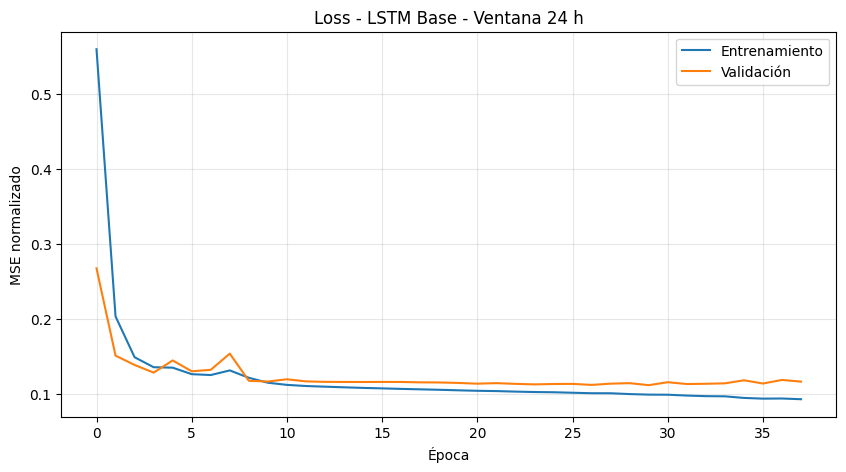

In [30]:
# Obtenemos la clave del mejor experimento.
best_key = (
    best_model_name,
    best_window_size
)

# Recuperamos su historial.
best_history = training_histories[
    best_key
]

# Creamos la gráfica.
plt.figure(
    figsize=(10, 5)
)

# Dibujamos la pérdida de entrenamiento.
plt.plot(
    best_history["loss"],
    label="Entrenamiento"
)

# Dibujamos la pérdida de validación.
plt.plot(
    best_history["val_loss"],
    label="Validación"
)

# Agregamos un título.
plt.title(
    f"Loss - {best_model_name} - Ventana {best_window_size} h"
)

# Nombramos el eje horizontal.
plt.xlabel(
    "Época"
)

# Nombramos el eje vertical.
plt.ylabel(
    "MSE normalizado"
)

# Mostramos la leyenda.
plt.legend()

# Activamos una cuadrícula.
plt.grid(
    alpha=0.3
)

# Mostramos la gráfica.
plt.show()

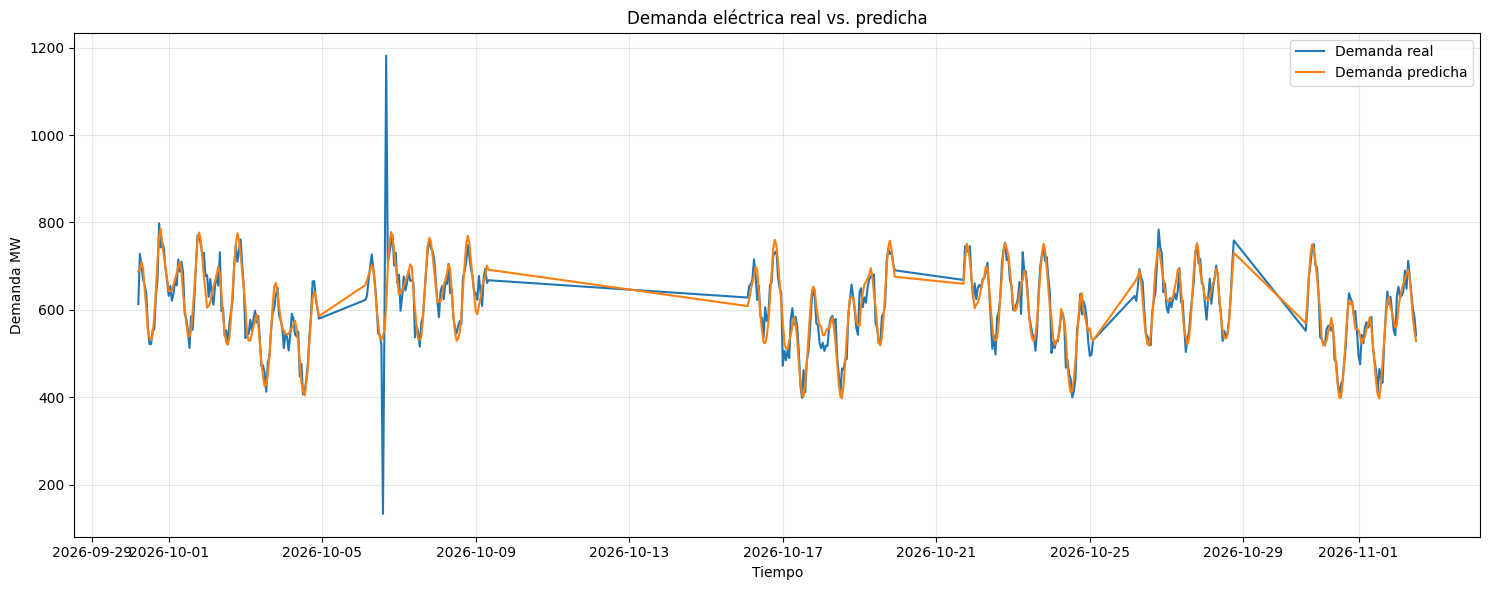

In [31]:
# Recuperamos las predicciones del mejor experimento.
best_predictions = prediction_store[
    best_key
]

# Limitamos la visualización para hacerla legible.
plot_data = best_predictions.iloc[
    :min(500, len(best_predictions))
]

# Creamos la figura.
plt.figure(
    figsize=(15, 6)
)

# Dibujamos la demanda real.
plt.plot(
    plot_data["timestamp"],
    plot_data["real"],
    label="Demanda real"
)

# Dibujamos la predicción.
plt.plot(
    plot_data["timestamp"],
    plot_data["predicted"],
    label="Demanda predicha"
)

# Agregamos título.
plt.title(
    "Demanda eléctrica real vs. predicha"
)

# Definimos el eje X.
plt.xlabel(
    "Tiempo"
)

# Definimos el eje Y.
plt.ylabel(
    "Demanda MW"
)

# Mostramos leyenda.
plt.legend()

# Activamos cuadrícula.
plt.grid(
    alpha=0.3
)

# Ajustamos automáticamente.
plt.tight_layout()

# Mostramos.
plt.show()

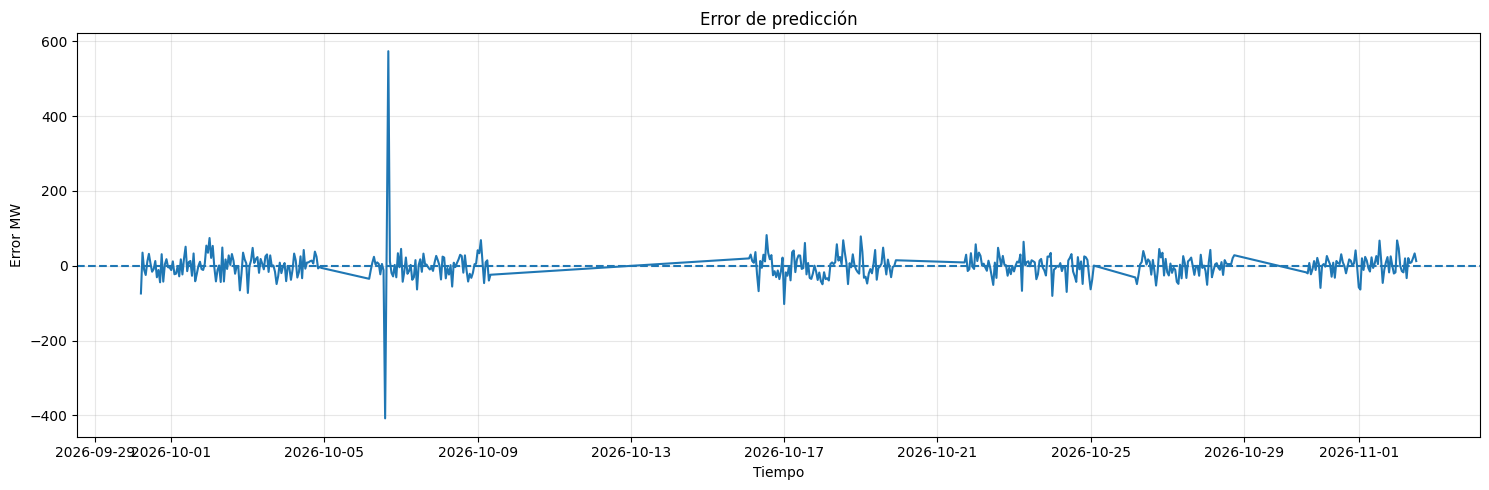

In [32]:
# Creamos la figura.
plt.figure(
    figsize=(15, 5)
)

# Dibujamos los errores.
plt.plot(
    plot_data["timestamp"],
    plot_data["error"]
)

# Dibujamos la línea de error cero.
plt.axhline(
    0,
    linestyle="--"
)

# Agregamos título.
plt.title(
    "Error de predicción"
)

# Nombramos el eje horizontal.
plt.xlabel(
    "Tiempo"
)

# Nombramos el eje vertical.
plt.ylabel(
    "Error MW"
)

# Activamos cuadrícula.
plt.grid(
    alpha=0.3
)

# Ajustamos diseño.
plt.tight_layout()

# Mostramos.
plt.show()

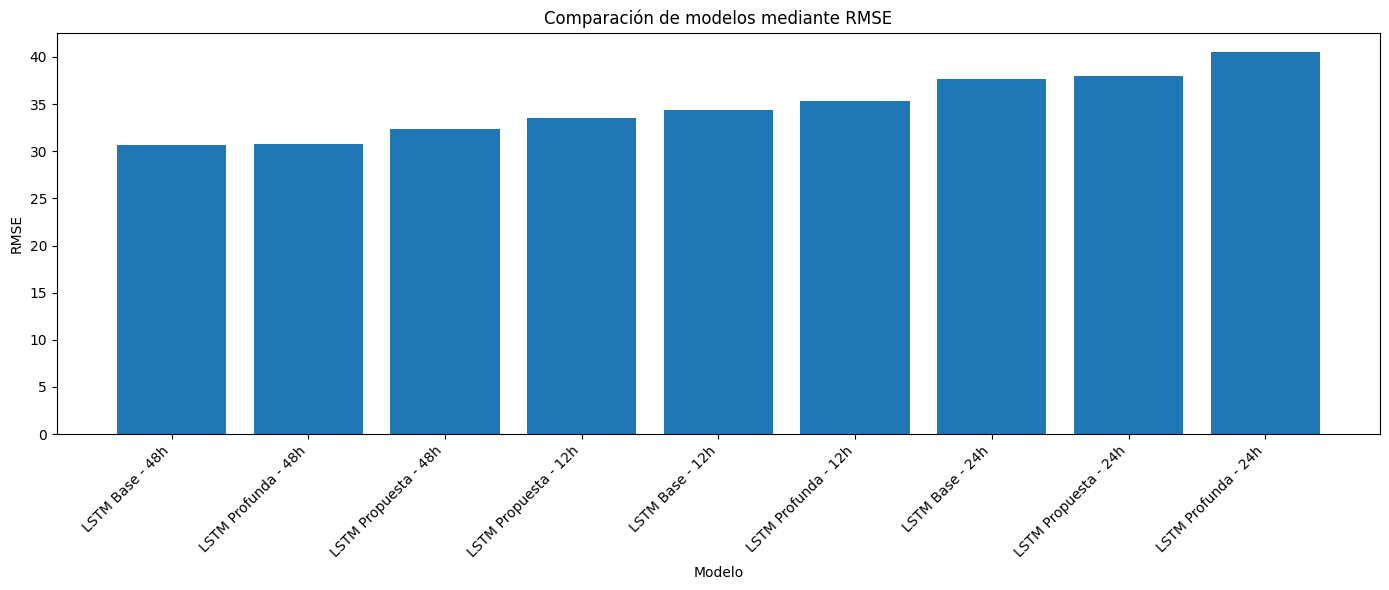

In [33]:
# Creamos una tabla auxiliar.
comparison_df = test_results_df.copy()

# Creamos una etiqueta combinando arquitectura y ventana.
comparison_df["Experimento"] = (
    comparison_df["Modelo"]
    + " - "
    + comparison_df["Ventana"].astype(str)
    + "h"
)

# Ordenamos por RMSE.
comparison_df = comparison_df.sort_values(
    "RMSE"
)

# Creamos la gráfica.
plt.figure(
    figsize=(14, 6)
)

# Dibujamos una barra por experimento.
plt.bar(
    comparison_df["Experimento"],
    comparison_df["RMSE"]
)

# Agregamos título.
plt.title(
    "Comparación de modelos mediante RMSE"
)

# Nombramos el eje horizontal.
plt.xlabel(
    "Modelo"
)

# Nombramos el eje vertical.
plt.ylabel(
    "RMSE"
)

# Rotamos las etiquetas.
plt.xticks(
    rotation=45,
    ha="right"
)

# Ajustamos diseño.
plt.tight_layout()

# Mostramos.
plt.show()

In [34]:
# Agrupamos los resultados por ventana.
window_comparison = (
    test_results_df
    .groupby("Ventana")[
        [
            "MAE",
            "RMSE",
            "MAPE",
            "R²"
        ]
    ]
    .mean()
)

# Mostramos el resultado.
display(window_comparison)

,MAE,RMSE,MAPE,R²
Ventana,,,,
12,22.029546,34.400661,3.904844,0.824272
24,24.294808,38.738521,4.381235,0.797749
48,24.153944,31.226555,4.110271,0.854577


In [35]:
# Obtenemos el mínimo loss de validación.
minimum_validation_loss = min(
    best_history["val_loss"]
)

# Obtenemos el último loss de validación.
last_validation_loss = best_history[
    "val_loss"
][-1]

# Obtenemos el último loss de entrenamiento.
last_training_loss = best_history[
    "loss"
][-1]

# Comprobamos si validación aumentó notablemente respecto de su mínimo.
possible_overfitting = (
    last_validation_loss
    > minimum_validation_loss * 1.10
)

# Mostramos información.
print(
    "Último loss entrenamiento:",
    last_training_loss
)

# Mostramos el mínimo de validación.
print(
    "Mejor loss validación:",
    minimum_validation_loss
)

# Mostramos el último valor.
print(
    "Último loss validación:",
    last_validation_loss
)

# Interpretamos el resultado.
if possible_overfitting:
    print(
        "Existe evidencia de sobreajuste al final del entrenamiento."
    )
else:
    print(
        "No se observa una separación fuerte que indique sobreajuste severo."
    )

Último loss entrenamiento: 0.0927136242389679
Mejor loss validación: 0.11147789657115936
Último loss validación: 0.11620815098285675
No se observa una separación fuerte que indique sobreajuste severo.


In [36]:
# Reconstruimos la ruta del mejor modelo.
safe_best_name = (
    best_model_name.lower()
    .replace(" ", "_")
    .replace("ó", "o")
)

# Construimos la ruta.
best_saved_model_path = model_directory / (
    f"{safe_best_name}_w{best_window_size}.keras"
)

# Cargamos el modelo ganador.
best_model = tf.keras.models.load_model(
    best_saved_model_path
)

# Creamos las secuencias correspondientes a la ventana ganadora.
best_sequence_data = create_sequences(
    scaled_features,
    scaled_target,
    df["timestamp"],
    best_window_size,
    train_cutoff,
    test_cutoff
)

# Extraemos la prueba.
X_test_best = best_sequence_data["X_test"]

# Extraemos y real.
y_test_best_scaled = best_sequence_data["y_test"]

# Recuperamos unidades reales.
y_test_best_real = target_scaler.inverse_transform(
    y_test_best_scaled.reshape(-1, 1)
).reshape(-1)

# Calculamos predicción original.
baseline_prediction_scaled = best_model.predict(
    X_test_best,
    verbose=0
)

# Recuperamos unidades.
baseline_prediction = target_scaler.inverse_transform(
    baseline_prediction_scaled
).reshape(-1)

# Calculamos MAE original.
baseline_mae = mean_absolute_error(
    y_test_best_real,
    baseline_prediction
)

# Creamos una lista para importancias.
feature_importance_rows = []

# Creamos un generador aleatorio reproducible.
rng = np.random.default_rng(
    RANDOM_SEED
)

# Recorremos cada característica.
for feature_index, feature_name in enumerate(feature_columns):
    # Creamos una copia del conjunto de prueba.
    permuted_X = X_test_best.copy()

    # Creamos una permutación de las secuencias.
    permutation = rng.permutation(
        len(permuted_X)
    )

    # Alteramos solamente la característica estudiada.
    permuted_X[:, :, feature_index] = (
        permuted_X[
            permutation,
            :,
            feature_index
        ]
    )

    # Generamos nuevas predicciones.
    permuted_prediction_scaled = best_model.predict(
        permuted_X,
        verbose=0
    )

    # Recuperamos unidades reales.
    permuted_prediction = target_scaler.inverse_transform(
        permuted_prediction_scaled
    ).reshape(-1)

    # Calculamos el nuevo MAE.
    permuted_mae = mean_absolute_error(
        y_test_best_real,
        permuted_prediction
    )

    # Calculamos cuánto empeoró.
    importance = (
        permuted_mae
        - baseline_mae
    )

    # Guardamos la información.
    feature_importance_rows.append(
        {
            "Variable": feature_name,
            "Incremento_MAE": importance
        }
    )

# Creamos el DataFrame.
feature_importance_df = pd.DataFrame(
    feature_importance_rows
)

# Ordenamos de mayor a menor importancia.
feature_importance_df = feature_importance_df.sort_values(
    "Incremento_MAE",
    ascending=False
).reset_index(drop=True)

# Mostramos los resultados.
display(feature_importance_df)

,Variable,Incremento_MAE
0,fin_semana,20.305138
1,periodo_dia_manana,10.101772
2,periodo_dia_tarde,7.390448
3,radiacion_wm2,6.642609
4,humedad_pct,4.818382
5,demanda_mw,4.107761
6,periodo_dia_madrugada,4.059507
7,hora,2.457222
8,dia_semana,2.332544
9,temperatura_c,2.272781


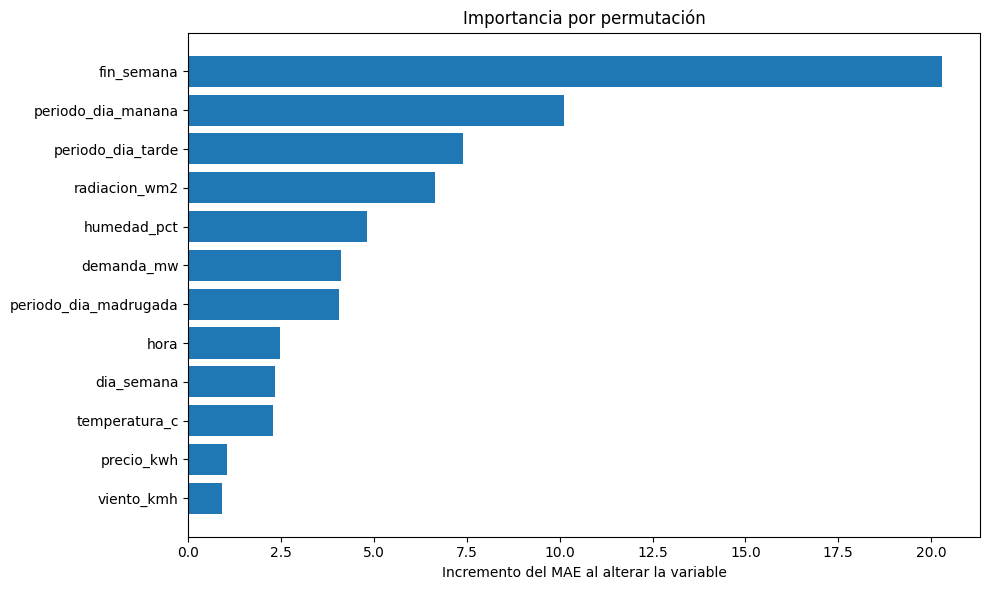

In [37]:
# Seleccionamos las variables más importantes.
top_features = feature_importance_df.head(12)

# Creamos la gráfica.
plt.figure(
    figsize=(10, 6)
)

# Dibujamos las barras.
plt.barh(
    top_features["Variable"],
    top_features["Incremento_MAE"]
)

# Invertimos para mostrar la más importante arriba.
plt.gca().invert_yaxis()

# Agregamos título.
plt.title(
    "Importancia por permutación"
)

# Nombramos el eje.
plt.xlabel(
    "Incremento del MAE al alterar la variable"
)

# Ajustamos.
plt.tight_layout()

# Mostramos.
plt.show()

In [38]:
# Creamos el directorio de deployment.
deployment_directory = Path(
    "/content/energy_demand_api"
)

# Creamos el directorio.
deployment_directory.mkdir(
    parents=True,
    exist_ok=True
)

# Definimos la ruta final del modelo.
production_model_path = (
    deployment_directory
    / "production_model.keras"
)

# Copiamos el modelo ganador.
shutil.copy(
    best_saved_model_path,
    production_model_path
)

# Mostramos confirmación.
print(
    "Modelo de producción:",
    production_model_path
)

Modelo de producción: /content/energy_demand_api/production_model.keras


In [39]:
# Creamos el paquete de preprocesamiento.
preprocessing_bundle = {
    "feature_scaler": feature_scaler,
    "target_scaler": target_scaler,
    "feature_columns": feature_columns,
    "window_size": best_window_size,
    "period_categories": period_categories,
    "train_cutoff": str(train_cutoff),
    "test_cutoff": str(test_cutoff),
    "model_name": best_model_name
}

# Definimos la ruta.
preprocessing_path = (
    deployment_directory
    / "preprocessing.pkl"
)

# Guardamos el archivo PKL.
joblib.dump(
    preprocessing_bundle,
    preprocessing_path
)

# Mostramos confirmación.
print(
    "Preprocesamiento guardado:",
    preprocessing_path
)

Preprocesamiento guardado: /content/energy_demand_api/preprocessing.pkl


In [40]:
# Obtenemos las métricas de prueba del modelo seleccionado.
selected_test_result = (
    pd.DataFrame(test_results)
    .query(
        "Modelo == @best_model_name and Ventana == @best_window_size"
    )
    .iloc[0]
)

# Construimos metadata legible.
metadata = {
    "problem": "Predicción de demanda eléctrica de la siguiente hora",
    "model": best_model_name,
    "window_hours": best_window_size,
    "validation_rmse": float(
        best_validation_result["RMSE"]
    ),
    "test_mae": float(
        selected_test_result["MAE"]
    ),
    "test_mse": float(
        selected_test_result["MSE"]
    ),
    "test_rmse": float(
        selected_test_result["RMSE"]
    ),
    "test_mape": float(
        selected_test_result["MAPE"]
    ),
    "test_r2": float(
        selected_test_result["R2"]
    ),
    "features": feature_columns
}

# Definimos el archivo JSON.
metadata_path = (
    deployment_directory
    / "metadata.json"
)

# Guardamos la metadata.
with open(
    metadata_path,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        metadata,
        file,
        ensure_ascii=False,
        indent=4
    )

# Mostramos metadata.
print(
    json.dumps(
        metadata,
        ensure_ascii=False,
        indent=4
    )
)

{
    "problem": "Predicción de demanda eléctrica de la siguiente hora",
    "model": "LSTM Base",
    "window_hours": 24,
    "validation_rmse": 31.246656071090232,
    "test_mae": 23.04131317138672,
    "test_mse": 1419.3875732421875,
    "test_rmse": 37.67476042713726,
    "test_mape": 4.174477577209473,
    "test_r2": 0.8089091777801514,
    "features": [
        "demanda_mw",
        "temperatura_c",
        "humedad_pct",
        "viento_kmh",
        "radiacion_wm2",
        "precipitacion_mm",
        "precio_kwh",
        "hora",
        "dia_semana",
        "fin_semana",
        "festivo",
        "mes",
        "periodo_dia_madrugada",
        "periodo_dia_manana",
        "periodo_dia_tarde",
        "periodo_dia_noche"
    ]
}


In [ ]:
# Importamos Markdown para mostrar el análisis de forma organizada.
from IPython.display import display, Markdown

# Convertimos nuevamente los resultados a DataFrame para facilitar el análisis.
test_analysis_df = pd.DataFrame(test_results)
validation_analysis_df = pd.DataFrame(validation_results)

# Obtenemos los resultados de prueba del modelo seleccionado mediante validación.
selected_test = test_analysis_df[
    (test_analysis_df["Modelo"] == best_model_name)
    & (test_analysis_df["Ventana"] == best_window_size)
].iloc[0]

# Obtenemos el mejor experimento únicamente para describir los resultados de prueba.
best_test_result = test_analysis_df.sort_values("RMSE").iloc[0]

# Calculamos el comportamiento promedio de cada ventana.
window_analysis = (
    test_analysis_df
    .groupby("Ventana")[["MAE", "RMSE", "MAPE", "R2"]]
    .mean()
    .sort_index()
)

# Calculamos el comportamiento promedio de cada arquitectura.
architecture_analysis = (
    test_analysis_df
    .groupby("Modelo")[["MAE", "RMSE", "MAPE", "R2"]]
    .mean()
    .sort_values("RMSE")
)

# Recuperamos las métricas de pérdida del modelo seleccionado.
minimum_validation_loss = min(best_history["val_loss"])
last_validation_loss = best_history["val_loss"][-1]
last_training_loss = best_history["loss"][-1]

# Calculamos cuánto aumentó la pérdida de validación respecto a su mejor punto.
validation_loss_increase = (
    (last_validation_loss - minimum_validation_loss)
    / minimum_validation_loss
) * 100

# Recuperamos la cantidad de épocas ejecutadas.
epochs_run = len(best_history["loss"])

# Recuperamos la mejor época.
best_epoch = int(np.argmin(best_history["val_loss"]) + 1)

# Calculamos cuántas épocas pasaron entre la mejor época y la detención.
epochs_after_best = epochs_run - best_epoch

# Calculamos cuánto aumentó el RMSE entre validación y prueba.
generalization_gap = (
    (selected_test["RMSE"] - best_validation_result["RMSE"])
    / best_validation_result["RMSE"]
) * 100

# Obtenemos los resultados promedio de cada arquitectura.
base_average = architecture_analysis.loc["LSTM Base"]
deep_average = architecture_analysis.loc["LSTM Profunda"]
proposed_average = architecture_analysis.loc["LSTM Propuesta"]

# Obtenemos las principales variables según importancia por permutación.
top_variables = feature_importance_df.head(6)

# Creamos una traducción más legible para las variables.
feature_names = {
    "fin_semana": "fin de semana",
    "periodo_dia_manana": "periodo de la mañana",
    "periodo_dia_tarde": "periodo de la tarde",
    "radiacion_wm2": "radiación solar",
    "humedad_pct": "humedad",
    "demanda_mw": "demanda histórica",
    "periodo_dia_madrugada": "periodo de la madrugada",
    "hora": "hora",
    "dia_semana": "día de la semana",
    "temperatura_c": "temperatura",
    "precio_kwh": "precio de la energía",
    "viento_kmh": "velocidad del viento",
    "festivo": "festivo",
    "periodo_dia_noche": "periodo de la noche",
    "precipitacion_mm": "precipitación",
    "mes": "mes"
}

# Construimos el texto de las variables más importantes.
feature_text = ""

# Recorremos las variables con mayor importancia.
for _, row in top_variables.iterrows():
    # Obtenemos el nombre legible.
    readable_name = feature_names.get(
        row["Variable"],
        row["Variable"]
    )

    # Agregamos la variable y el incremento del MAE.
    feature_text += (
        f"- **{readable_name}:** incremento del MAE de "
        f"{row['Incremento_MAE']:.2f} MW al alterar sus valores.\n"
    )

# Obtenemos los valores promedio por ventana.
window_12 = window_analysis.loc[12]
window_24 = window_analysis.loc[24]
window_48 = window_analysis.loc[48]

# Construimos todo el análisis final.
analysis_text = f"""
# Análisis de resultados de los modelos LSTM

Los siguientes resultados corresponden a los experimentos ejecutados con las
arquitecturas LSTM Base, LSTM Profunda y LSTM Propuesta utilizando ventanas
temporales de 12, 24 y 48 horas.

---

## 1. ¿Por qué LSTM es apropiada para este problema?

Los resultados obtenidos muestran que las arquitecturas LSTM fueron capaces de
aprender relaciones temporales presentes en la demanda eléctrica.

El modelo seleccionado mediante validación fue **{best_model_name} con una ventana
de {best_window_size} horas**, alcanzando un **RMSE de validación de
{best_validation_result["RMSE"]:.2f} MW**.

En el conjunto de prueba este modelo obtuvo:

- **MAE:** {selected_test["MAE"]:.2f} MW.
- **MSE:** {selected_test["MSE"]:.2f}.
- **RMSE:** {selected_test["RMSE"]:.2f} MW.
- **MAPE:** {selected_test["MAPE"]:.2f} %.
- **R²:** {selected_test["R2"]:.4f}.

El R² de **{selected_test["R2"]:.4f}** indica que el modelo seleccionado explica
aproximadamente el **{selected_test["R2"] * 100:.1f} % de la variabilidad de la
demanda** presente en el conjunto de prueba.

Además, el mejor resultado observado dentro del conjunto de prueba correspondió
a **{best_test_result["Modelo"]} con {int(best_test_result["Ventana"])} horas**,
con un RMSE de **{best_test_result["RMSE"]:.2f} MW** y un R² de
**{best_test_result["R2"]:.4f}**.

Estos resultados respaldan el uso de LSTM porque la demanda actual depende del
comportamiento de horas anteriores y de variables que evolucionan en el tiempo.

---

## 2. ¿Qué efecto tiene cambiar la ventana temporal?

El cambio de ventana produjo diferencias claras en el comportamiento de los
modelos.

### Ventana de 12 horas
- MAE promedio: **{window_12["MAE"]:.2f} MW**.
- RMSE promedio: **{window_12["RMSE"]:.2f} MW**.
- MAPE promedio: **{window_12["MAPE"]:.2f} %**.
- R² promedio: **{window_12["R2"]:.4f}**.

### Ventana de 24 horas
- MAE promedio: **{window_24["MAE"]:.2f} MW**.
- RMSE promedio: **{window_24["RMSE"]:.2f} MW**.
- MAPE promedio: **{window_24["MAPE"]:.2f} %**.
- R² promedio: **{window_24["R2"]:.4f}**.

### Ventana de 48 horas
- MAE promedio: **{window_48["MAE"]:.2f} MW**.
- RMSE promedio: **{window_48["RMSE"]:.2f} MW**.
- MAPE promedio: **{window_48["MAPE"]:.2f} %**.
- R² promedio: **{window_48["R2"]:.4f}**.

Al comparar los resultados de prueba, la ventana de **48 horas obtuvo el menor
RMSE promedio ({window_48["RMSE"]:.2f} MW) y el mayor R² promedio
({window_48["R2"]:.4f})**. Esto indica que disponer de dos días de información
histórica ayudó a los modelos a capturar mejor algunos patrones de la demanda.

Sin embargo, la ventana de **12 horas presentó el menor MAE promedio
({window_12["MAE"]:.2f} MW)**, mientras que la ventana de 24 horas presentó un
RMSE promedio mayor.

Por lo tanto, aumentar la ventana temporal no produjo una mejora lineal. El
efecto depende tanto de la arquitectura como de la métrica utilizada.

---

## 3. ¿Existe sobreajuste?

Para el modelo seleccionado se obtuvo:

- Último loss de entrenamiento: **{last_training_loss:.4f}**.
- Mejor loss de validación: **{minimum_validation_loss:.4f}**.
- Último loss de validación: **{last_validation_loss:.4f}**.

Después de alcanzar el mejor valor de validación, la pérdida aumentó solamente
un **{validation_loss_increase:.2f} %**.

Por esta razón, **no se observa un sobreajuste severo**. Existe una diferencia
normal entre entrenamiento y validación, pero la pérdida de validación no presentó
un crecimiento suficientemente grande como para indicar que el modelo estuviera
memorizando el conjunto de entrenamiento.

El Early Stopping también evitó continuar innecesariamente el entrenamiento
cuando la validación dejó de mejorar.

---

## 4. ¿Qué es y qué efecto tiene Dropout?

Dropout es una técnica de regularización que desactiva aleatoriamente una parte
de las neuronas durante el entrenamiento. Su objetivo es reducir la dependencia
excesiva entre neuronas y disminuir el riesgo de sobreajuste.

En este experimento se utilizó Dropout en las arquitecturas **LSTM Profunda** y
**LSTM Propuesta**, mientras que la **LSTM Base no utilizó Dropout**.

Los RMSE promedio obtenidos fueron:

- LSTM Base: **{base_average["RMSE"]:.2f} MW**.
- LSTM Profunda: **{deep_average["RMSE"]:.2f} MW**.
- LSTM Propuesta: **{proposed_average["RMSE"]:.2f} MW**.

En este caso, agregar Dropout junto con arquitecturas más complejas ayudó a
controlar el sobreajuste, pero **no produjo por sí solo un mejor resultado que
la arquitectura base**.

Esto demuestra que Dropout es una herramienta de regularización y no una garantía
de obtener métricas superiores.

---

## 5. ¿Qué es y qué efecto tiene Early Stopping?

Early Stopping detiene el entrenamiento cuando la métrica de validación deja de
mejorar durante un número determinado de épocas.

El modelo seleccionado ejecutó **{epochs_run} épocas**, pero su mejor resultado
de validación se alcanzó en la época **{best_epoch}**.

Después de esta época transcurrieron **{epochs_after_best} épocas sin obtener una
mejora suficiente**, por lo que Early Stopping detuvo el entrenamiento y restauró
los pesos correspondientes al mejor punto.

En este experimento, Early Stopping permitió evitar entrenamiento innecesario y
reducir el riesgo de sobreajuste.

---

## 6. ¿Más neuronas implican necesariamente mejores resultados?

**No.**

Los resultados obtenidos lo demuestran directamente.

La arquitectura LSTM Base, que es la más sencilla, obtuvo un RMSE promedio de
**{base_average["RMSE"]:.2f} MW**, mientras que:

- LSTM Profunda: **{deep_average["RMSE"]:.2f} MW**.
- LSTM Propuesta: **{proposed_average["RMSE"]:.2f} MW**.

La LSTM Profunda utilizó más neuronas y más capas, y la arquitectura propuesta
incorporó además convolución y atención. Sin embargo, ninguna superó de forma
general a la arquitectura base.

Esto indica que incrementar el número de neuronas o la complejidad puede aumentar
la capacidad del modelo, pero también puede dificultar la generalización o hacer
que el modelo aprenda relaciones que no aportan mejoras reales.

Por lo tanto, **más neuronas no significan necesariamente mayor precisión**.

---

## 7. ¿Qué modelo recomendaría para producción y por qué?

El modelo recomendado para producción es **{best_model_name} con una ventana de
{best_window_size} horas**.

La razón principal es que fue el modelo seleccionado correctamente mediante el
conjunto de **validación**, donde alcanzó el menor RMSE:
**{best_validation_result["RMSE"]:.2f} MW**.

Posteriormente, al evaluarlo con datos de prueba obtuvo:

- MAE: **{selected_test["MAE"]:.2f} MW**.
- RMSE: **{selected_test["RMSE"]:.2f} MW**.
- MAPE: **{selected_test["MAPE"]:.2f} %**.
- R²: **{selected_test["R2"]:.4f}**.

Aunque **{best_test_result["Modelo"]} con {int(best_test_result["Ventana"])} horas**
obtuvo posteriormente el menor RMSE del conjunto de prueba
(**{best_test_result["RMSE"]:.2f} MW**), no sería correcto cambiar el modelo
seleccionado únicamente después de observar los resultados de prueba, porque el
conjunto de prueba debe conservarse como una evaluación final independiente.

Por ello, para esta ejecución se mantiene como candidato de producción la
**{best_model_name} de {best_window_size} horas**.

Además, al ser una arquitectura más sencilla presenta ventajas para producción:
menor complejidad, menor costo computacional y mayor facilidad de mantenimiento.

---

## 8. ¿Qué variables pueden influir más en la demanda?

De acuerdo con el análisis de importancia por permutación del modelo seleccionado,
las variables que produjeron el mayor incremento del error al modificar sus valores
fueron:

{feature_text}

La variable con mayor influencia fue **{feature_names.get(top_variables.iloc[0]["Variable"], top_variables.iloc[0]["Variable"])}**,
ya que al alterar sus valores el MAE aumentó aproximadamente
**{top_variables.iloc[0]["Incremento_MAE"]:.2f} MW**.

También tuvieron una influencia importante el periodo del día, la radiación,
la humedad y la demanda histórica.

Estos resultados indican qué variables son más importantes para las predicciones
del modelo entrenado. Sin embargo, la importancia por permutación representa
**importancia predictiva y no necesariamente causalidad**.

---

## 9. ¿Qué limitaciones tiene el modelo?

A partir de los resultados obtenidos se identifican varias limitaciones.

Primero, existe una diferencia entre el rendimiento de validación y prueba. El
RMSE pasó de **{best_validation_result["RMSE"]:.2f} MW en validación** a
**{selected_test["RMSE"]:.2f} MW en prueba**, lo que corresponde a un aumento
aproximado del **{generalization_gap:.2f} %**. Esto muestra que el rendimiento
puede variar cuando el modelo recibe datos completamente nuevos.

Segundo, el modelo fue entrenado para predecir únicamente la demanda de
**la siguiente hora**, por lo que estos resultados no pueden extrapolarse
directamente a predicciones de 6, 12 o 24 horas.

Tercero, la precisión depende de la calidad y disponibilidad de variables como
temperatura, humedad, radiación, precipitación, precio y datos temporales.

Cuarto, pueden aparecer cambios futuros en los patrones de consumo energético
que no estén representados en los datos utilizados para entrenar el modelo.
Este fenómeno puede generar **data drift** y requerir reentrenamiento.

Quinto, aunque se probaron tres arquitecturas y tres ventanas, todavía podrían
evaluarse otras combinaciones de hiperparámetros, regularización y características.

Finalmente, la importancia de variables obtenida mediante permutación permite
interpretar el comportamiento predictivo del modelo, pero no permite afirmar que
una variable sea la causa directa de los cambios en la demanda.

---

## Conclusión general

Después de ejecutar los nueve experimentos se determinó que aumentar la
complejidad de la arquitectura no garantizó mejores resultados.

La **LSTM Base** presentó un comportamiento competitivo frente a las arquitecturas
Profunda y Propuesta. La selección mediante validación determinó que la
configuración **{best_model_name} con una ventana de {best_window_size} horas**
era la candidata más adecuada de acuerdo con el criterio definido.

El modelo logró un R² de prueba de **{selected_test["R2"]:.4f}** y un MAPE de
**{selected_test["MAPE"]:.2f} %**, mostrando que fue capaz de aprender gran parte
del comportamiento temporal de la demanda energética.

Los experimentos también mostraron que la ventana temporal, la regularización
y la cantidad de neuronas deben evaluarse empíricamente, ya que una arquitectura
más compleja no necesariamente ofrece una mejor capacidad de generalización.
"""

# Mostramos las respuestas directamente debajo de la celda.
display(Markdown(analysis_text))